# Software Defect Prediction

**Author:** David Snyder  
**Course:** UC Berkeley Executive Education – Machine Learning and Artificial Intelligence  
**Project:** Software Defect Prediction  
**Date:** August 2026

This notebook explores whether code-level metrics can be used to identify defect-prone code. The analysis starts with a broad comparison of classification models, tunes the strongest candidates, and then looks more closely at Gradient Boosting.

The second half of the notebook focuses on feature importance and feature pruning. It also tests whether a smaller set of shared static-code metrics can generalize to two external PROMISE datasets: ANT 1.7 and Synapse 1.2.

The goal is not only to find the strongest model, but also to understand which code characteristics are most useful and how well those relationships transfer across software projects.


In [1]:
# Core data and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_score,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

# Neural network
import tensorflow as tf

## 1. Load and Inspect the Data

Start by loading the baseline dataset and checking its basic structure. These checks help catch missing values, duplicates, or unexpected data types before modeling.


In [2]:
# Load the code-metrics dataset
df = pd.read_csv("data/baseline.csv")

df.head()

,SHA,cbo,wmc,dit,rfc,lcom,totalMethods,totalFields,nosi,loc,...,tryCatchQty,parenthesizedExpsQty,stringLiteralsQty,numbersQty,assignmentsQty,mathOperationsQty,variablesQty,maxNestedBlocks,uniqueWordsQty,defect
0,7a955fd6c7de2bd912be544dcfe77f9173a7aa600,5,60,2,55,189,27,5,30,247,...,4,2,47,9,27,5,17,3,191,0
1,000f1ab4780fc9460975791c52597f7c04e15be70,3,10,1,1,9,7,4,1,38,...,0,0,0,22,4,0,4,2,69,0
2,000f1ab4780fc9460975791c52597f7c04e15be71,3,10,1,1,9,7,4,0,38,...,0,0,0,22,4,0,4,2,69,1
3,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c270,20,59,3,63,189,24,9,4,262,...,0,6,6,14,45,8,41,4,222,0
4,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c271,21,58,2,61,189,24,9,0,260,...,0,6,6,14,45,8,41,4,222,1


In [3]:
# Basic data-quality checks before doing any modeling
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Data types:
SHA                       str
cbo                     int64
wmc                     int64
dit                     int64
rfc                     int64
lcom                    int64
totalMethods            int64
totalFields             int64
nosi                    int64
loc                     int64
returnQty               int64
loopQty                 int64
comparisonsQty          int64
tryCatchQty             int64
parenthesizedExpsQty    int64
stringLiteralsQty       int64
numbersQty              int64
assignmentsQty          int64
mathOperationsQty       int64
variablesQty            int64
maxNestedBlocks         int64
uniqueWordsQty          int64
defect                  int64
dtype: object

Missing values:
SHA                     0
cbo                     0
wmc                     0
dit                     0
rfc                     0
lcom                    0
totalMethods            0
totalFields             0
nosi                    0
loc                     0
return

## 2. Rename Columns for Readability

The original dataset uses abbreviated metric names. Renaming them makes the later analysis easier to read without changing the underlying data.


In [4]:
# Replace abbreviated metric names with more descriptive labels
column_names = {
    "SHA": "commit_hash",
    "cbo": "coupling_between_objects",
    "wmc": "weighted_methods_per_class",
    "dit": "depth_of_inheritance_tree",
    "rfc": "response_for_class",
    "lcom": "lack_of_cohesion_in_methods",
    "totalMethods": "total_methods",
    "totalFields": "total_fields",
    "nosi": "number_of_static_invocations",
    "loc": "lines_of_code",
    "returnQty": "return_statement_count",
    "loopQty": "loop_count",
    "comparisonsQty": "comparison_count",
    "tryCatchQty": "try_catch_count",
    "parenthesizedExpsQty": "parenthesized_expression_count",
    "stringLiteralsQty": "string_literal_count",
    "numbersQty": "numeric_literal_count",
    "assignmentsQty": "assignment_count",
    "mathOperationsQty": "math_operation_count",
    "variablesQty": "variable_count",
    "maxNestedBlocks": "maximum_nested_blocks",
    "uniqueWordsQty": "unique_word_count",
    "defect": "defect"
}

df = df.rename(columns=column_names)
df.head()

,commit_hash,coupling_between_objects,weighted_methods_per_class,depth_of_inheritance_tree,response_for_class,lack_of_cohesion_in_methods,total_methods,total_fields,number_of_static_invocations,lines_of_code,...,try_catch_count,parenthesized_expression_count,string_literal_count,numeric_literal_count,assignment_count,math_operation_count,variable_count,maximum_nested_blocks,unique_word_count,defect
0,7a955fd6c7de2bd912be544dcfe77f9173a7aa600,5,60,2,55,189,27,5,30,247,...,4,2,47,9,27,5,17,3,191,0
1,000f1ab4780fc9460975791c52597f7c04e15be70,3,10,1,1,9,7,4,1,38,...,0,0,0,22,4,0,4,2,69,0
2,000f1ab4780fc9460975791c52597f7c04e15be71,3,10,1,1,9,7,4,0,38,...,0,0,0,22,4,0,4,2,69,1
3,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c270,20,59,3,63,189,24,9,4,262,...,0,6,6,14,45,8,41,4,222,0
4,0024dbdd6ba3cc7797cc0b1ae537dcdc488c4c271,21,58,2,61,189,24,9,0,260,...,0,6,6,14,45,8,41,4,222,1


## 3. Exploratory Analysis

Before training models, check the target distribution and review summary statistics for the numeric features.


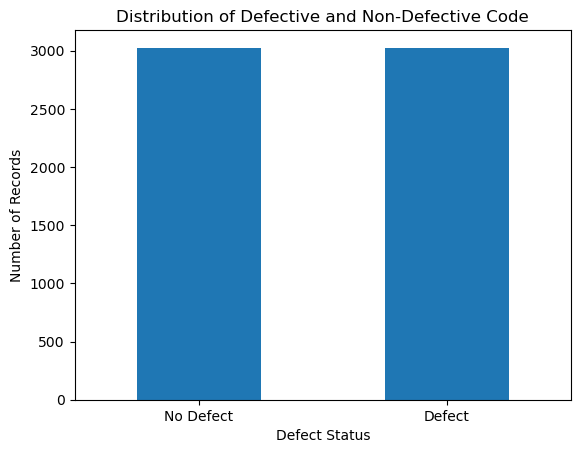

In [5]:
# Check whether defective and non-defective records are reasonably balanced
df["defect"].value_counts().sort_index().plot(
    kind="bar",
    title="Distribution of Defective and Non-Defective Code"
)

plt.xlabel("Defect Status")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["No Defect", "Defect"], rotation=0)
plt.show()

In [6]:
# Exclude the identifier and target so we can summarize only the model features
feature_df = df.drop(columns=["commit_hash", "defect"])
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
coupling_between_objects,6052.0,27.493721,33.214827,0.0,9.0,18.0,34.00,419.0
weighted_methods_per_class,6052.0,86.177958,136.077153,0.0,18.0,45.0,100.00,1714.0
depth_of_inheritance_tree,6052.0,4.599141,9.288447,1.0,1.0,2.0,4.00,285.0
response_for_class,6052.0,68.954395,85.771623,0.0,18.0,44.0,89.00,1203.0
lack_of_cohesion_in_methods,6052.0,1242.030238,9449.009245,0.0,4.0,43.0,267.00,199855.0
total_methods,6052.0,33.497852,53.556999,0.0,8.0,17.0,39.00,758.0
total_fields,6052.0,14.049405,26.051029,0.0,3.0,7.0,18.00,903.0
number_of_static_invocations,6052.0,5.945142,25.263058,0.0,0.0,0.0,3.00,475.0
lines_of_code,6052.0,442.074190,681.566084,6.0,93.0,230.0,521.25,8832.0
return_statement_count,6052.0,25.410112,47.058370,0.0,4.0,12.0,28.00,579.0


## 4. Prepare Training and Test Data

`commit_hash` is an identifier rather than a predictive code metric, so it is excluded from the features. The data is split with stratification so the defect ratio stays similar in both sets.


In [7]:
# Separate predictor variables from the defect target
X = df.drop(columns=["commit_hash", "defect"])
y = df["defect"]

In [8]:
# Keep 20% of the data untouched for final model evaluation
# Stratification preserves the class distribution across the split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 5. Establish a Simple Baseline

A dummy classifier provides a minimum benchmark. Any useful model should improve meaningfully on this baseline, especially for F1 and recall.


In [9]:
# Predict the most common class every time to create a simple reference point
dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)

print(
    "Dummy Model Accuracy:",
    accuracy_score(y_test, dummy_predictions)
)

print(
    "Dummy Model F1 Score:",
    f1_score(y_test, dummy_predictions, zero_division=0)
)

Dummy Model Accuracy: 0.4995871180842279
Dummy Model F1 Score: 0.6662995594713657


## 6. Logistic Regression Baseline

Logistic regression gives a straightforward, interpretable model. Standardization is included in a pipeline so scaling is learned only from the training data.


In [10]:
# Make and fit a logistic regression pipeline
# Scale the numeric features before logistic regression
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_pipe.fit(X_train, y_train)

lr_pred = lr_pipe.predict(X_test)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.78      0.60      0.68       606
           1       0.67      0.83      0.74       605

    accuracy                           0.72      1211
   macro avg       0.73      0.72      0.71      1211
weighted avg       0.73      0.72      0.71      1211



In [11]:
# Review several metrics instead of relying on accuracy alone
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))

Accuracy: 0.7151114781172585
Precision: 0.6742627345844504
Recall: 0.8314049586776859
F1 Score: 0.7446336047372317
ROC-AUC: 0.7789447126530835


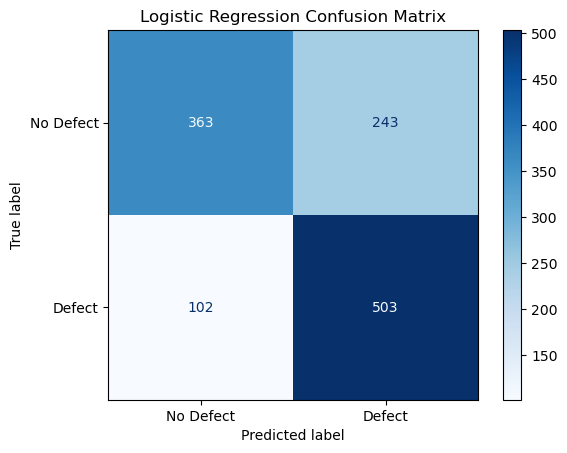

In [12]:
# The confusion matrix makes false positives and false negatives easier to see
# This is important as the false negatives represent hot areas that could lead to bugs
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["No Defect", "Defect"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [13]:
# Logistic regression coefficients give a rough sense of which features have the 
#   strongest relationship with the model's prediction
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_pipe.named_steps["model"].coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)


,Feature,Coefficient,Absolute Coefficient
7,number_of_static_invocations,-2.233759,2.233759
2,depth_of_inheritance_tree,-0.630585,0.630585
0,coupling_between_objects,0.621650,0.621650
3,response_for_class,-0.516396,0.516396
8,lines_of_code,0.425657,0.425657
11,comparison_count,-0.284650,0.284650
9,return_statement_count,0.266654,0.266654
1,weighted_methods_per_class,0.259216,0.259216
4,lack_of_cohesion_in_methods,-0.226864,0.226864
5,total_methods,-0.179976,0.179976


## 7. Compare Multiple Classification Models

Next, compare several model types using five-fold stratified cross-validation on the training set. This gives a more reliable comparison than judging each model from a single split.

The models below use reasonable starting settings rather than exhaustive tuning.


In [14]:
# Define a set of candidate models to compare under the same CV process
# This way we can loop through them and easily build a comparison chart
candidate_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ])
}


In [15]:
# Use the same stratified folds for every model so the comparison stays fair
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# Loop through the models and cross validate them
for name, model in candidate_models.items():
    print("Cross validating: ", name)
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(cv_results).sort_values(
    "F1",
    ascending=False
)

results_df


Cross validating:  Logistic Regression
Cross validating:  Decision Tree
Cross validating:  Random Forest
Cross validating:  Extra Trees
Cross validating:  Gradient Boosting
Cross validating:  SVM


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,Gradient Boosting,0.785581,0.761747,0.831479,0.795042,0.833051
1,Decision Tree,0.778558,0.766415,0.801741,0.783453,0.827474
2,Random Forest,0.762445,0.747859,0.792237,0.769380,0.796097
0,Logistic Regression,0.726090,0.685075,0.838096,0.753664,0.790802
3,Extra Trees,0.719684,0.702121,0.763735,0.731599,0.735546
5,SVM,0.670724,0.619300,0.886819,0.729255,0.773565


## 8. Tune the Stronger Tree-Based Models

Grid search is used to tune the Decision Tree, Random Forest, and Gradient Boosting models. F1 is the optimization metric so the search balances precision and recall instead of favoring only one side.


### Decision Tree


In [16]:
# Explore tree depth, split requirements, feature selection, and class weighting
tree_params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best parameters:", tree_grid.best_params_)
print("Best cross-validation F1:", tree_grid.best_score_)


Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best cross-validation F1: 0.8005939733185613


### Random Forest


In [17]:
# Tune the number and complexity of trees in the forest
rf_params = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation F1:", rf_grid.best_score_)


Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 400}
Best cross-validation F1: 0.8079032610549033


### Gradient Boosting


In [18]:
# Keep this grid smaller so tuning remains manageable
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 5, 10],
    "subsample": [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_params,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best parameters:", gb_grid.best_params_)
print("Best cross-validation F1:", gb_grid.best_score_)


Best parameters: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation F1: 0.8058657541902473


## 9. Evaluate the Tuned Gradient Boosting Model

The best Gradient Boosting configuration is evaluated on the held-out test set. The confusion matrix is especially useful here because false negatives represent real defects the model failed to flag.


              precision    recall  f1-score   support

           0       0.81      0.71      0.76       606
           1       0.74      0.84      0.79       605

    accuracy                           0.77      1211
   macro avg       0.78      0.77      0.77      1211
weighted avg       0.78      0.77      0.77      1211

Accuracy: 0.772914946325351
Precision: 0.7412280701754386
Recall: 0.8380165289256198
F1: 0.7866563227307991
ROC-AUC: 0.8116916237078254


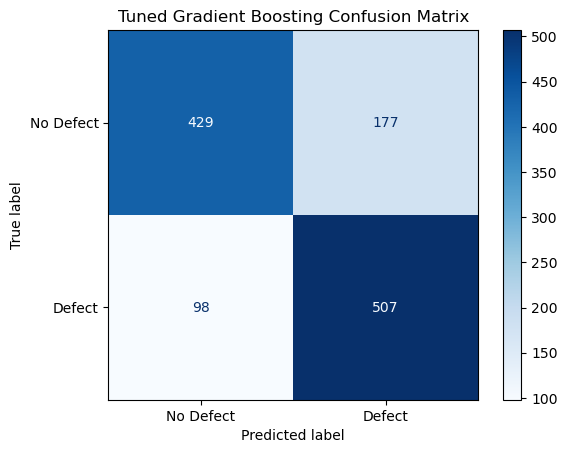

In [19]:
best_gb = gb_grid.best_estimator_

gb_predictions = best_gb.predict(X_test)
gb_probabilities = best_gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_predictions))

print("Accuracy:", accuracy_score(y_test, gb_predictions))
print("Precision:", precision_score(y_test, gb_predictions))
print("Recall:", recall_score(y_test, gb_predictions))
print("F1:", f1_score(y_test, gb_predictions))
print("ROC-AUC:", roc_auc_score(y_test, gb_probabilities))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_predictions,
    display_labels=["No Defect", "Defect"],
    cmap="Blues"
)

plt.title("Tuned Gradient Boosting Confusion Matrix")
plt.show()


## 10. Compare the Tuned Models on the Test Set

Now compare the best version of each tuned tree-based model against the same untouched test data.


In [20]:
tuned_models = {
    "Tuned Decision Tree": tree_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

tuned_comparison = []

# Loop through the models to build the comparison chart
for name, model in tuned_models.items():
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    tuned_comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

comparison_df = pd.DataFrame(tuned_comparison).sort_values(
    "F1",
    ascending=False
)

comparison_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Tuned Random Forest,0.774566,0.743402,0.838017,0.787879,0.803504
2,Tuned Gradient Boosting,0.772915,0.741228,0.838017,0.786656,0.811692
0,Tuned Decision Tree,0.754748,0.709239,0.862810,0.778523,0.806985


## 11. TensorFlow Neural Network

A small feed-forward neural network provides a different modeling approach. A validation split is taken only from the training data, so the final test set remains untouched until evaluation.


In [21]:
# Create a validation set from the training data for neural-network tuning
# Neural network variables include "nn" in their names to distinguish them from the other models
X_nn_train, X_nn_val, y_nn_train, y_nn_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

# Standardize the numeric features
nn_scaler = StandardScaler()
X_nn_train_scaled = nn_scaler.fit_transform(X_nn_train)
X_nn_val_scaled = nn_scaler.transform(X_nn_val)
X_test_scaled = nn_scaler.transform(X_test)

# Use float32 arrays, since TensorFlow works with those
X_nn_train_scaled = X_nn_train_scaled.astype("float32")
X_nn_val_scaled = X_nn_val_scaled.astype("float32")
X_test_scaled = X_test_scaled.astype("float32")

y_nn_train_array = y_nn_train.to_numpy().astype("float32")
y_nn_val_array = y_nn_val.to_numpy().astype("float32")
y_test_array = y_test.to_numpy().astype("float32")


In [22]:
# Set the TensorFlow seed to make results reproducible
tf.random.set_seed(42)

number_of_features = X_nn_train_scaled.shape[1]

# Use a compact network to test whether a neural approach adds value
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(number_of_features,)),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.10),

    tf.keras.layers.Dense(16, activation="relu"),

    # Sigmoid returns the probability of the positive class (defect)
    tf.keras.layers.Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc")
    ]
)

nn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Stop training when validation loss stops improving and restore the best weights
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

nn_history = nn_model.fit(
    X_nn_train_scaled,
    y_nn_train_array,
    validation_data=(
        X_nn_val_scaled,
        y_nn_val_array
    ),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5266 - loss: 0.6931 - precision: 0.5192 - recall: 0.7211 - roc_auc: 0.5422 - val_accuracy: 0.5686 - val_loss: 0.6807 - val_precision: 0.5523 - val_recall: 0.7299 - val_roc_auc: 0.6070
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5752 - loss: 0.6813 - precision: 0.5711 - recall: 0.6033 - roc_auc: 0.6067 - val_accuracy: 0.6388 - val_loss: 0.6731 - val_precision: 0.6427 - val_recall: 0.6268 - val_roc_auc: 0.6688
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5984 - loss: 0.6718 - precision: 0.5971 - recall: 0.6049 - roc_auc: 0.6471 - val_accuracy: 0.6502 - val_loss: 0.6661 - val_precision: 0.6281 - val_recall: 0.7381 - val_roc_auc: 0.6930
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6237 - loss: 0.6636 - precision: 0.6120 - recall: 0.6761 - roc_auc: 0.6728 - val_accuracy: 0.6656 - val_loss: 0.6575 - val_precision: 0.6477 - val_recall: 0.7278 - val_roc_auc: 0.

### Neural Network Evaluation


In [24]:
# Convert predicted probabilities into class labels using the standard 0.50 threshold
nn_probabilities = nn_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

nn_predictions = (nn_probabilities >= 0.50).astype(int)

print(classification_report(
    y_test,
    nn_predictions,
    target_names=["No Defect", "Defect"]
))

print("Accuracy:", accuracy_score(y_test, nn_predictions))
print("Precision:", precision_score(y_test, nn_predictions))
print("Recall:", recall_score(y_test, nn_predictions))
print("F1:", f1_score(y_test, nn_predictions))
print("ROC-AUC:", roc_auc_score(y_test, nn_probabilities))


              precision    recall  f1-score   support

   No Defect       0.79      0.71      0.75       606
      Defect       0.73      0.81      0.77       605

    accuracy                           0.76      1211
   macro avg       0.76      0.76      0.76      1211
weighted avg       0.76      0.76      0.76      1211

Accuracy: 0.7588769611890999
Precision: 0.7339312406576981
Recall: 0.8115702479338843
F1: 0.7708006279434851
ROC-AUC: 0.8087185991326404


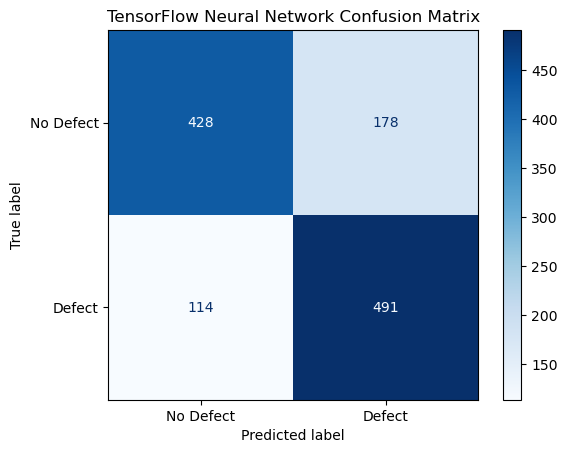

In [25]:
# Display false negatives in the bottom-left of the matrix, since those are the 
#   possible leaked defects
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_predictions,
    display_labels=["No Defect", "Defect"],
    cmap="Blues"
)

plt.title("TensorFlow Neural Network Confusion Matrix")
plt.show()


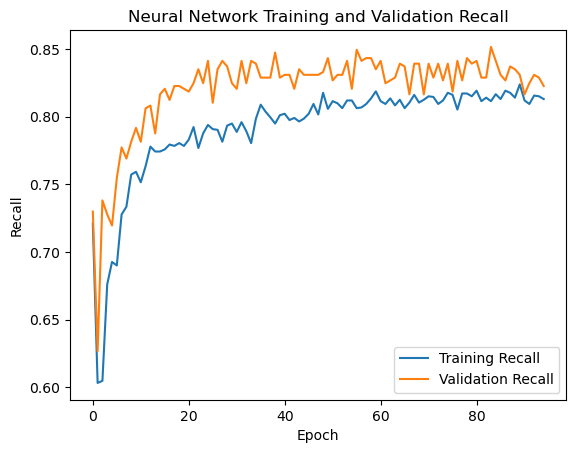

In [26]:
# Compare training and validation recall to watch for overfitting
plt.plot(
    nn_history.history["recall"],
    label="Training Recall"
)

plt.plot(
    nn_history.history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Neural Network Training and Validation Recall")
plt.legend()
plt.show()


## 12. Final Model Comparison

Combine the neural-network results with the tuned traditional models so their test-set performance can be reviewed side by side.


In [27]:
neural_network_results = pd.DataFrame([{
    "Model": "TensorFlow Neural Network",
    "Accuracy": accuracy_score(y_test, nn_predictions),
    "Precision": precision_score(y_test, nn_predictions),
    "Recall": recall_score(y_test, nn_predictions),
    "F1": f1_score(y_test, nn_predictions),
    "ROC-AUC": roc_auc_score(y_test, nn_probabilities)
}])

final_comparison_df = pd.concat(
    [
        comparison_df,
        neural_network_results
    ],
    ignore_index=True
).sort_values(
    "F1",
    ascending=False
)

final_comparison_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest,0.774566,0.743402,0.838017,0.787879,0.803504
1,Tuned Gradient Boosting,0.772915,0.741228,0.838017,0.786656,0.811692
2,Tuned Decision Tree,0.754748,0.709239,0.862810,0.778523,0.806985
3,TensorFlow Neural Network,0.758877,0.733931,0.811570,0.770801,0.808719


## 13. Model Selection and Threshold Analysis

The tuned Random Forest and Gradient Boosting models perform very similarly on the held-out test set. Gradient Boosting is used for the deeper analysis because it has the strongest ROC-AUC while maintaining competitive F1 and recall.

Because false negatives represent actual defects that the model misses, the classification threshold is also examined. Lowering the threshold can improve recall, but the tradeoff is more false positives.


In [28]:
# Evaluate how changing the probability cutoff affects precision, recall, and F1
# The default binary-classification threshold is 0.50
classification_thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in classification_thresholds:
    threshold_predictions = (gb_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_predictions),
        "Recall": recall_score(y_test, threshold_predictions),
        "F1": f1_score(y_test, threshold_predictions)
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df


,Threshold,Precision,Recall,F1
0,0.20,0.701072,0.864463,0.774241
1,0.25,0.702957,0.864463,0.775389
2,0.30,0.704453,0.862810,0.775632
3,0.35,0.707317,0.862810,0.777364
4,0.40,0.712722,0.861157,0.779940
5,0.45,0.724965,0.849587,0.782344
6,0.50,0.741228,0.838017,0.786656
7,0.55,0.751938,0.801653,0.776000
8,0.60,0.764706,0.773554,0.769104
9,0.65,0.779690,0.748760,0.763912


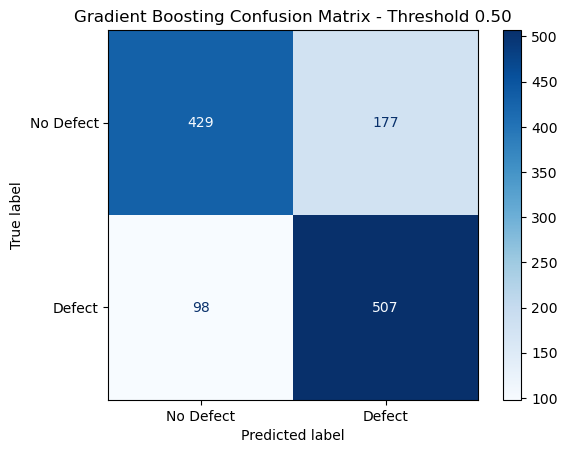

Threshold: 0.50
Precision: 0.7412
Recall:    0.8380
F1:        0.7867



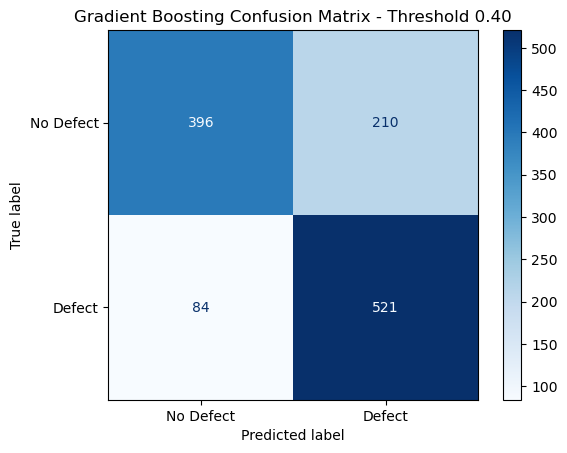

Threshold: 0.40
Precision: 0.7127
Recall:    0.8612
F1:        0.7799



In [29]:
# Compare the default threshold with 0.40, which improves recall while
#   keeping the drop in precision and F1 fairly modest.
thresholds_to_compare = [0.50, 0.40]

for threshold in thresholds_to_compare:
    threshold_predictions = (gb_probabilities >= threshold).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        threshold_predictions,
        display_labels=["No Defect", "Defect"],
        cmap="Blues"
    )

    plt.title(f"Gradient Boosting Confusion Matrix - Threshold {threshold:.2f}")
    plt.show()

    print(f"Threshold: {threshold:.2f}")
    print(f"Precision: {precision_score(y_test, threshold_predictions):.4f}")
    print(f"Recall:    {recall_score(y_test, threshold_predictions):.4f}")
    print(f"F1:        {f1_score(y_test, threshold_predictions):.4f}")
    print()


### Threshold takeaway

Lowering the Gradient Boosting threshold from **0.50 to 0.40** reduced false negatives from **98 to 84**, allowing the model to catch **14 additional actual defects**. The tradeoff was an increase in false positives from **177 to 210**.

The default 0.50 threshold still has the best F1 score, but 0.40 is a reasonable option when avoiding missed defects is more important than minimizing extra reviews.


## 14. Feature Importance and Feature Pruning

The next step is to move beyond model scores and look at which code metrics are actually driving the predictions.

Gradient Boosting provides built-in feature importance values. Features with very small importance values are treated as candidates for removal, then the reduced model is retrained and compared with the full model. Cross-validation is used to check whether the simpler feature set holds up beyond a single test split.


In [30]:
# Rank the original features by their contribution to the tuned Gradient Boosting model
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance


,Feature,Importance
7,number_of_static_invocations,0.818359
8,lines_of_code,0.032993
2,depth_of_inheritance_tree,0.031527
0,coupling_between_objects,0.031050
17,math_operation_count,0.025984
16,assignment_count,0.016798
12,try_catch_count,0.009147
3,response_for_class,0.008608
18,variable_count,0.007919
14,string_literal_count,0.003465


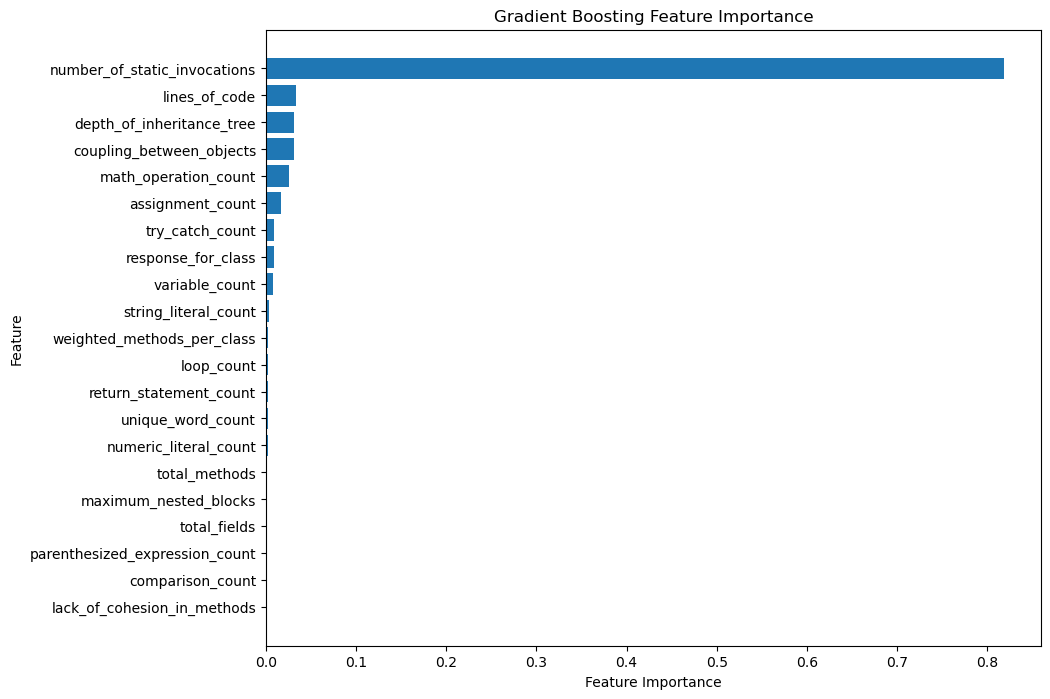

In [31]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [32]:
# Start by inspecting features below a 0.01 importance threshold
# This is just an experimental cutoff
feature_importance[
    feature_importance["Importance"] < 0.01
]


,Feature,Importance
12,try_catch_count,0.009147
3,response_for_class,0.008608
18,variable_count,0.007919
14,string_literal_count,0.003465
1,weighted_methods_per_class,0.002759
10,loop_count,0.002655
9,return_statement_count,0.002294
20,unique_word_count,0.002068
15,numeric_literal_count,0.001895
5,total_methods,0.001555


In [33]:
# Cumulative importance helps show how concentrated the model is
#   around its strongest predictors
feature_importance["Cumulative Importance"] = (
    feature_importance["Importance"].cumsum()
)

feature_importance


,Feature,Importance,Cumulative Importance
7,number_of_static_invocations,0.818359,0.818359
8,lines_of_code,0.032993,0.851352
2,depth_of_inheritance_tree,0.031527,0.882878
0,coupling_between_objects,0.031050,0.913929
17,math_operation_count,0.025984,0.939912
16,assignment_count,0.016798,0.956711
12,try_catch_count,0.009147,0.965858
3,response_for_class,0.008608,0.974466
18,variable_count,0.007919,0.982385
14,string_literal_count,0.003465,0.985850


In [34]:
# Treat the lowest-importance features as candidates for pruning
low_importance_features = feature_importance[
    feature_importance["Importance"] < 0.01
]["Feature"].tolist()

low_importance_features


['try_catch_count',
 'response_for_class',
 'variable_count',
 'string_literal_count',
 'weighted_methods_per_class',
 'loop_count',
 'return_statement_count',
 'unique_word_count',
 'numeric_literal_count',
 'total_methods',
 'maximum_nested_blocks',
 'total_fields',
 'parenthesized_expression_count',
 'comparison_count',
 'lack_of_cohesion_in_methods']

In [35]:
# Create reduced train/test sets using the same original split
X_train_reduced = X_train.drop(columns=low_importance_features)
X_test_reduced = X_test.drop(columns=low_importance_features)


In [36]:
# Clone the tuned model so its hyperparameters stay the same
# Only the feature set changes in this comparison
gb_reduced = clone(best_gb)

# Train the reduced set
gb_reduced.fit(X_train_reduced, y_train)

y_pred_reduced = gb_reduced.predict(X_test_reduced)
y_prob_reduced = gb_reduced.predict_proba(X_test_reduced)[:, 1]


In [37]:
# Evaluate the pruned model on the held-out test set
print("Reduced-feature Gradient Boosting")
print("---------------------------------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_reduced):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_reduced):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_reduced):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_reduced):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_reduced):.4f}")


Reduced-feature Gradient Boosting
---------------------------------
Accuracy:  0.7737
Precision: 0.7409
Recall:    0.8413
F1:        0.7879
ROC-AUC:   0.8151


### Feature Pruning Validation

Several feature-importance thresholds are compared using five-fold cross-validation to determine how much the model can be simplified without sacrificing predictive performance. This helps verify that removing low-importance features produces consistent results across multiple training folds rather than appearing effective only on a single train/test split.

In [38]:
# Compare several pruning thresholds with five-fold cross-validation
# This helps avoid choosing a reduced feature set based only on test performance
importance_thresholds = [0, 0.005, 0.01]

feature_selection_results = []

for importance_threshold in importance_thresholds:

    # Select the features above the threshold
    selected_features_cv = feature_importance[
        feature_importance["Importance"] >= importance_threshold
    ]["Feature"].tolist()

    X_train_subset = X_train[selected_features_cv]

    # Clone the model, don't use the original
    model = clone(best_gb)

    scores = cross_val_score(
        model,
        X_train_subset,
        y_train,
        cv=cv,
        scoring="f1"
    )

    feature_selection_results.append({
        "Importance Threshold": importance_threshold,
        "Number of Features": len(selected_features_cv),
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

feature_selection_results_df = pd.DataFrame(feature_selection_results)
feature_selection_results_df


,Importance Threshold,Number of Features,Mean CV F1,Std CV F1
0,0.000,21,0.805866,0.007817
1,0.005,9,0.807899,0.005392
2,0.010,6,0.807679,0.006555


In [39]:
# The 0.01 threshold keeps six features while maintaining a strong
#   mean cross-validation F1 of the thresholds tested
selected_features = feature_importance[
    feature_importance["Importance"] >= 0.01
]["Feature"].tolist()

selected_features


['number_of_static_invocations',
 'lines_of_code',
 'depth_of_inheritance_tree',
 'coupling_between_objects',
 'math_operation_count',
 'assignment_count']

### Selected feature interpretation

Using a 0.01 importance cutoff reduces the model from **21 features to 6** without hurting cross-validation performance. The retained features are:

- **number_of_static_invocations** — how often static methods or functions are invoked.
- **lines_of_code** — a basic measure of code size.
- **depth_of_inheritance_tree** — how deep a class sits in an inheritance hierarchy.
- **coupling_between_objects** — how strongly a class depends on other classes.
- **math_operation_count** — the amount of mathematical logic in the code.
- **assignment_count** — the number of assignments or state changes.

The full model reached a mean CV F1 of about **0.806**, while the six-feature version reached about **0.808**. The difference is small, so the main benefit is simplicity: most of the original features can be removed without sacrificing predictive performance.


## 15. Cross-Project Validation with Shared Static-Code Metrics

The six features selected above are not all available in the PROMISE datasets, so a separate set of **six directly comparable metrics** is used for external validation:

- weighted methods per class
- depth of inheritance tree
- coupling between objects
- response for class
- lack of cohesion in methods
- lines of code

The external PROMISE datasets used in this analysis were obtained from the GitHub repository associated with the software defect prediction research:

**Source:** [SDP using DQN-based feature extraction](https://github.com/asqwq/SDP-using-DQN-based-feature-extraction)

This is a different six-feature set from the feature-pruned model above. The purpose here is to create an apples-to-apples comparison across datasets rather than claim that these are the six strongest predictors in the original data.

A Gradient Boosting model is first trained on the original dataset using only these shared metrics. That same fitted model is then evaluated on ANT and Synapse without retraining. Separate within-project models are also trained as controls.

In [40]:
# Six static-code metrics that exist in the original, ANT, and Synapse datasets
common_features = [
    "weighted_methods_per_class",
    "depth_of_inheritance_tree",
    "coupling_between_objects",
    "response_for_class",
    "lack_of_cohesion_in_methods",
    "lines_of_code"
]

# Restrict the original dataset to the features that can be compared externally
X_common = df[common_features].copy()
y_common = df["defect"].copy()

print("Original shared-feature dataset shape:", X_common.shape)
X_common.head()


Original shared-feature dataset shape: (6052, 6)


,weighted_methods_per_class,depth_of_inheritance_tree,coupling_between_objects,response_for_class,lack_of_cohesion_in_methods,lines_of_code
0,60,2,5,55,189,247
1,10,1,3,1,9,38
2,10,1,3,1,9,38
3,59,3,20,63,189,262
4,58,2,21,61,189,260


In [41]:
# Use the same split strategy as the main analysis
X_common_train, X_common_test, y_common_train, y_common_test = train_test_split(
    X_common,
    y_common,
    test_size=0.20,
    random_state=42,
    stratify=y_common
)


In [42]:
# Keep the tuned Gradient Boosting hyperparameters but retrain using
# only the six features that are shared across datasets
gb_common = clone(best_gb)
gb_common.fit(X_common_train, y_common_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [43]:
# Establish the in-dataset baseline for this shared six-feature model
y_common_pred = gb_common.predict(X_common_test)
y_common_prob = gb_common.predict_proba(X_common_test)[:, 1]

print("Six-feature model on original test data")
print("---------------------------------------")
print(f"Accuracy:  {accuracy_score(y_common_test, y_common_pred):.4f}")
print(f"Precision: {precision_score(y_common_test, y_common_pred):.4f}")
print(f"Recall:    {recall_score(y_common_test, y_common_pred):.4f}")
print(f"F1:        {f1_score(y_common_test, y_common_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_common_test, y_common_prob):.4f}")


Six-feature model on original test data
---------------------------------------
Accuracy:  0.6433
Precision: 0.6349
Recall:    0.6727
F1:        0.6533
ROC-AUC:   0.6745


### 15.1 ANT 1.7 External Validation

ANT uses abbreviated PROMISE metric names, so the overlapping columns are renamed to match the original dataset. The `bug` field is a defect count; it is converted to a binary target where zero means no defect and any positive value means defective.

Two evaluations are performed:

1. **Original → ANT:** test the model trained on the original dataset directly on ANT.
2. **ANT → ANT:** train and test a separate model within ANT as a control.


In [44]:
# Load ANT 1.7
ant_df = pd.read_csv("data/ant-1.7.csv")

print("ANT shape:", ant_df.shape)
ant_df.head()


ANT shape: (745, 21)


,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,lcom3,...,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,3,1,0,10,18,3,1,9,1,1.100,...,0.0,0,0.0,0.444444,0,0,32.666667,1,0.6667,0
1,5,2,0,4,13,0,1,4,4,0.625,...,1.0,1,0.7,0.500000,0,0,13.400000,1,0.6000,0
2,1,2,0,1,3,0,0,1,1,2.000,...,0.0,0,1.0,1.000000,0,0,6.000000,0,0.0000,0
3,8,1,9,13,20,12,9,4,8,0.800,...,0.2,1,0.0,0.406250,0,0,11.000000,1,0.8750,0
4,9,3,0,5,26,16,0,5,7,0.750,...,1.0,0,0.8,0.388889,0,0,19.000000,2,1.0000,1


In [45]:
# Rename PROMISE metrics so the feature names match the original dataset
ant_df = ant_df.rename(columns={
    "wmc": "weighted_methods_per_class",
    "dit": "depth_of_inheritance_tree",
    "cbo": "coupling_between_objects",
    "rfc": "response_for_class",
    "lcom": "lack_of_cohesion_in_methods",
    "loc": "lines_of_code",
    "bug": "defect"
})


In [46]:
# Keep only the six comparable predictors and the target
ant_reduced = ant_df[
    common_features + ["defect"]
].copy()

ant_reduced.head()


,weighted_methods_per_class,depth_of_inheritance_tree,coupling_between_objects,response_for_class,lack_of_cohesion_in_methods,lines_of_code,defect
0,3,1,10,18,3,106,0
1,5,2,4,13,0,76,0
2,1,2,1,3,0,7,0
3,8,1,13,20,12,101,0
4,9,3,5,26,16,185,1


In [47]:
# Quick data-quality check before external validation
ant_reduced.info()

print("\nMissing values:")
print(ant_reduced.isna().sum())

print("\nRaw defect-count distribution:")
print(ant_reduced["defect"].value_counts().sort_index())


<class 'pandas.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   weighted_methods_per_class   745 non-null    int64
 1   depth_of_inheritance_tree    745 non-null    int64
 2   coupling_between_objects     745 non-null    int64
 3   response_for_class           745 non-null    int64
 4   lack_of_cohesion_in_methods  745 non-null    int64
 5   lines_of_code                745 non-null    int64
 6   defect                       745 non-null    int64
dtypes: int64(7)
memory usage: 40.9 KB

Missing values:
weighted_methods_per_class     0
depth_of_inheritance_tree      0
coupling_between_objects       0
response_for_class             0
lack_of_cohesion_in_methods    0
lines_of_code                  0
defect                         0
dtype: int64

Raw defect-count distribution:
defect
0     579
1      93
2      30
3      16
4      15
5       4
6   

In [48]:
# Convert defect counts into the same binary target used by the original model
# 0 = no defect, 1 = one or more defects
ant_reduced["defect"] = (ant_reduced["defect"] > 0).astype(int)

print("Class distribution:")
print(ant_reduced["defect"].value_counts())

# Summarize the binary defect distribution for ANT
ant_defect_count = ant_reduced["defect"].sum()
ant_total_count = len(ant_reduced)
ant_defect_rate = ant_reduced["defect"].mean()

print(f"\nTotal modules:     {ant_total_count}")
print(f"Defective modules: {ant_defect_count}")
print(f"Defect rate:       {ant_defect_rate:.1%}")


Class distribution:
defect
0    579
1    166
Name: count, dtype: int64

Total modules:     745
Defective modules: 166
Defect rate:       22.3%


In [49]:
X_ant = ant_reduced[common_features]
y_ant = ant_reduced["defect"]


In [50]:
# External validation: do NOT refit gb_common on ANT here
# This measures how well the original project's learned relationships transfer
y_ant_pred = gb_common.predict(X_ant)
y_ant_prob = gb_common.predict_proba(X_ant)[:, 1]

print("Original-trained model evaluated on ANT")
print("---------------------------------------")
print(f"Accuracy:  {accuracy_score(y_ant, y_ant_pred):.4f}")
print(f"Precision: {precision_score(y_ant, y_ant_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_ant, y_ant_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_ant, y_ant_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_ant, y_ant_prob):.4f}")


Original-trained model evaluated on ANT
---------------------------------------
Accuracy:  0.6309
Precision: 0.2116
Recall:    0.2410
F1:        0.2254
ROC-AUC:   0.5081


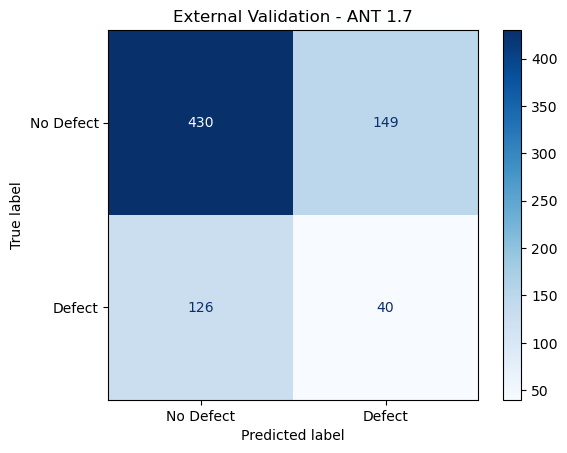

In [51]:
ConfusionMatrixDisplay.from_predictions(
    y_ant,
    y_ant_pred,
    display_labels=["No Defect", "Defect"],
    cmap="Blues"
)

plt.title("External Validation - ANT 1.7")
plt.show()


In [52]:
# Control experiment: train and test a separate model within ANT
X_ant_train, X_ant_test, y_ant_train, y_ant_test = train_test_split(
    X_ant,
    y_ant,
    test_size=0.20,
    random_state=42,
    stratify=y_ant
)

gb_ant = clone(best_gb)
gb_ant.fit(X_ant_train, y_ant_train)

y_ant_pred_local = gb_ant.predict(X_ant_test)
y_ant_prob_local = gb_ant.predict_proba(X_ant_test)[:, 1]

print("Model trained and tested on ANT")
print("--------------------------------")
print(f"Accuracy:  {accuracy_score(y_ant_test, y_ant_pred_local):.4f}")
print(f"Precision: {precision_score(y_ant_test, y_ant_pred_local, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_ant_test, y_ant_pred_local, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_ant_test, y_ant_pred_local, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_ant_test, y_ant_prob_local):.4f}")


Model trained and tested on ANT
--------------------------------
Accuracy:  0.8188
Precision: 0.6364
Recall:    0.4242
F1:        0.5091
ROC-AUC:   0.8017


In [53]:
# Compare feature distributions to look for evidence of dataset shift
ant_feature_comparison = pd.DataFrame({
    "Original Mean": X_common.mean(),
    "ANT Mean": X_ant.mean(),
    "Original Median": X_common.median(),
    "ANT Median": X_ant.median(),
    "Original Std": X_common.std(),
    "ANT Std": X_ant.std()
})

ant_feature_comparison


,Original Mean,ANT Mean,Original Median,ANT Median,Original Std,ANT Std
weighted_methods_per_class,86.177958,11.071141,45.0,7.0,136.077153,11.975963
depth_of_inheritance_tree,4.599141,2.522148,2.0,2.0,9.288447,1.398869
coupling_between_objects,27.493721,11.046980,18.0,6.0,33.214827,26.343149
response_for_class,68.954395,34.362416,44.0,23.0,85.771623,36.024972
lack_of_cohesion_in_methods,1242.030238,89.147651,43.0,6.0,9449.009245,349.937555
lines_of_code,442.074190,280.071141,230.0,143.0,681.566084,411.872075


### Feature Distribution Comparison

The original-trained model performed much worse when evaluated on ANT than when the same model configuration was trained directly on ANT. One possible explanation is that the underlying feature distributions differ substantially between the two projects.

The following boxplots compare the six shared static-code metrics between the original dataset and ANT. Because several of these metrics are highly skewed and contain large outliers, a `log1p` transformation is used to make the distributions easier to compare visually.

These plots help identify potential dataset shift, where the model encounters feature values and distributions that differ from those seen during training. This may help explain why the relationships learned from the original dataset do not transfer well to ANT.

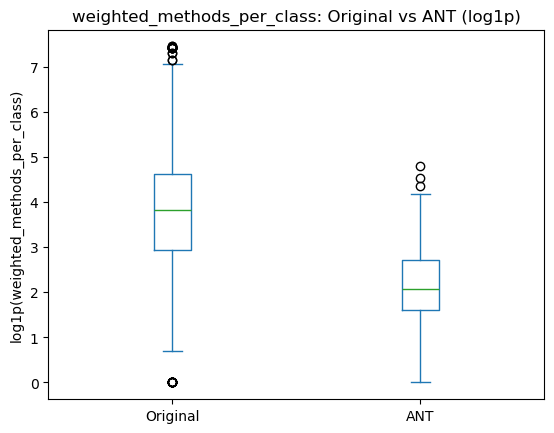

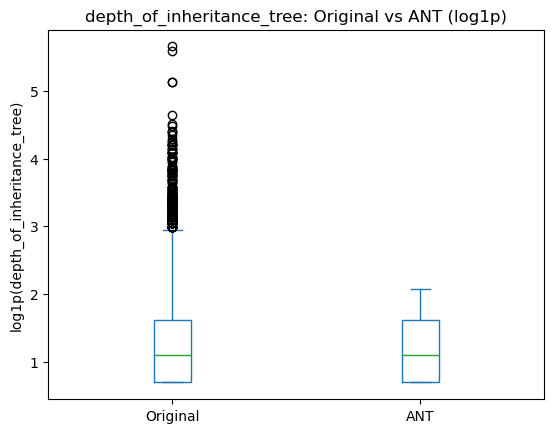

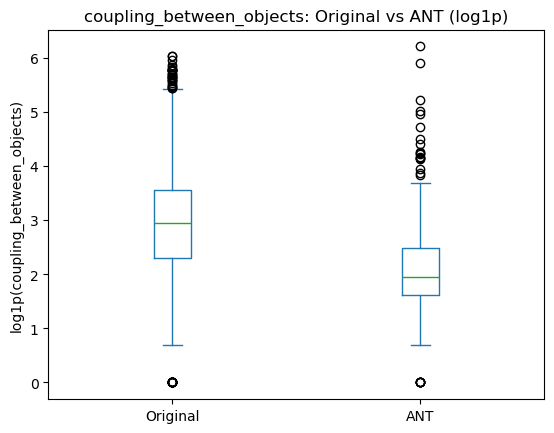

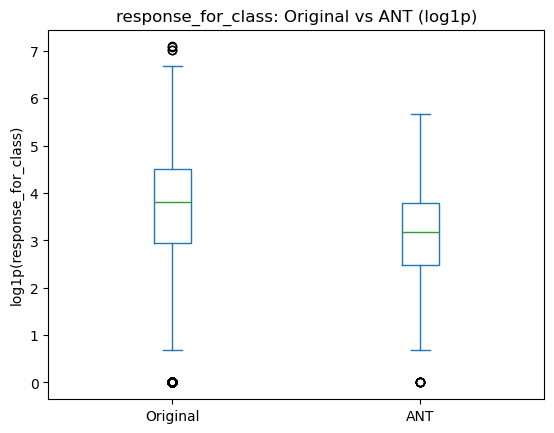

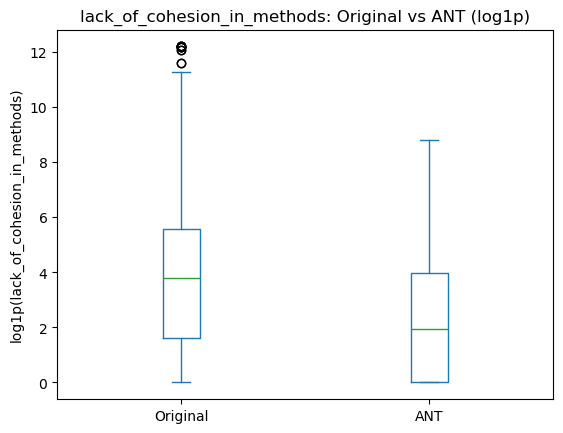

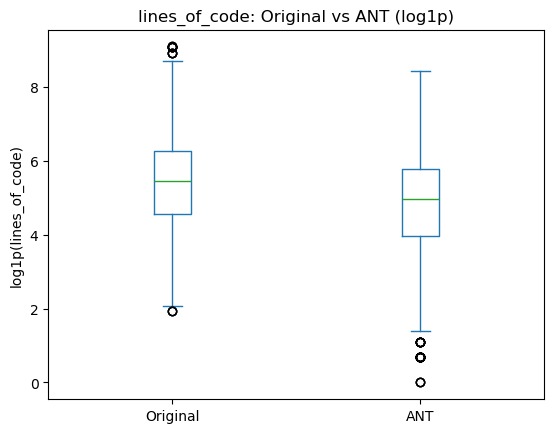

In [54]:
# These metrics are heavily skewed, so log1p makes the boxplots easier to compare
for feature in common_features:
    feature_distribution = pd.DataFrame({
        "Original": np.log1p(X_common[feature]),
        "ANT": np.log1p(X_ant[feature])
    })

    feature_distribution.plot(
        kind="box",
        title=f"{feature}: Original vs ANT (log1p)"
    )

    plt.ylabel(f"log1p({feature})")
    plt.show()


### 15.2 Synapse 1.2 External Validation

Synapse is processed with the same six shared metrics and binary defect definition used for ANT. Its defect rate is more moderate than ANT's, which provides another useful test of cross-project generalization.

As with ANT, the original-trained model is evaluated first, followed by a separate model trained and tested locally on Synapse.


In [55]:
# Load Synapse 1.2.
synapse_df = pd.read_csv("data/synapse-1.2.csv")

print("Synapse shape:", synapse_df.shape)
print("\nColumns:")
print(synapse_df.columns.tolist())

synapse_df.head()


Synapse shape: (256, 24)

Columns:
['name', 'version', 'name.1', 'wmc', 'dit', 'noc', 'cbo', 'rfc', 'lcom', 'ca', 'ce', 'npm', 'lcom3', 'loc', 'dam', 'moa', 'mfa', 'cam', 'ic', 'cbm', 'amc', 'max_cc', 'avg_cc', 'bug']


,name,version,name.1,wmc,dit,noc,cbo,rfc,lcom,ca,...,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,synapse,1.2,org.apache.synapse.endpoints.LoadbalanceEndpoint,15,1,0,18,52,37,3,...,1.0,4,0.0,0.255102,0,0,16.533333,13,2.0667,1
1,synapse,1.2,org.apache.synapse.util.concurrent.SynapseThre...,3,3,0,2,8,3,1,...,0.0,0,1.0,0.555556,0,0,15.000000,0,0.0000,0
2,synapse,1.2,org.apache.synapse.mediators.AbstractMediator,15,1,18,23,33,7,18,...,1.0,0,0.0,0.380952,0,0,14.066667,4,2.3333,4
3,synapse,1.2,org.apache.synapse.config.xml.AnonymousListMed...,2,3,0,6,5,1,2,...,0.0,0,0.8,0.500000,0,0,6.000000,1,0.5000,0
4,synapse,1.2,org.apache.synapse.endpoints.algorithms.Loadba...,2,1,0,11,2,1,8,...,0.0,0,0.0,0.833333,0,0,0.000000,1,1.0000,1


In [56]:
# Rename the overlapping PROMISE metrics to match the original dataset
synapse_df = synapse_df.rename(columns={
    "wmc": "weighted_methods_per_class",
    "dit": "depth_of_inheritance_tree",
    "cbo": "coupling_between_objects",
    "rfc": "response_for_class",
    "lcom": "lack_of_cohesion_in_methods",
    "loc": "lines_of_code",
    "bug": "defect"
})

synapse_reduced = synapse_df[
    common_features + ["defect"]
].copy()

synapse_reduced.head()


,weighted_methods_per_class,depth_of_inheritance_tree,coupling_between_objects,response_for_class,lack_of_cohesion_in_methods,lines_of_code,defect
0,15,1,18,52,37,271,1
1,3,3,2,8,3,60,0
2,15,1,23,33,7,229,4
3,2,3,6,5,1,14,0
4,2,1,11,2,1,2,1


In [57]:
# Convert the defect count to a binary target
# 0 = no defect, 1 = one or more defects
synapse_reduced["defect"] = (
    synapse_reduced["defect"] > 0
).astype(int)

print("Class distribution:")
print(synapse_reduced["defect"].value_counts())

# Summarize the binary defect distribution for Synapse
synapse_defect_count = synapse_reduced["defect"].sum()
synapse_total_count = len(synapse_reduced)
synapse_defect_rate = synapse_reduced["defect"].mean()

print(f"\nTotal modules:     {synapse_total_count}")
print(f"Defective modules: {synapse_defect_count}")
print(f"Defect rate:       {synapse_defect_rate:.1%}")


Class distribution:
defect
0    170
1     86
Name: count, dtype: int64

Total modules:     256
Defective modules: 86
Defect rate:       33.6%


In [58]:
# Confirm that the reduced external dataset is complete
print("Missing values:")
print(synapse_reduced.isna().sum())


Missing values:
weighted_methods_per_class     0
depth_of_inheritance_tree      0
coupling_between_objects       0
response_for_class             0
lack_of_cohesion_in_methods    0
lines_of_code                  0
defect                         0
dtype: int64


In [59]:
X_synapse = synapse_reduced[common_features]
y_synapse = synapse_reduced["defect"]

# External validation: use the model trained on the original dataset as-is
y_synapse_pred = gb_common.predict(X_synapse)
y_synapse_prob = gb_common.predict_proba(X_synapse)[:, 1]

print("Original-trained model evaluated on Synapse")
print("--------------------------------------------")
print(f"Accuracy:  {accuracy_score(y_synapse, y_synapse_pred):.4f}")
print(f"Precision: {precision_score(y_synapse, y_synapse_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_synapse, y_synapse_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_synapse, y_synapse_pred, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_synapse, y_synapse_prob):.4f}")


Original-trained model evaluated on Synapse
--------------------------------------------
Accuracy:  0.5625
Precision: 0.3917
Recall:    0.5465
F1:        0.4563
ROC-AUC:   0.5554


In [60]:
# Control experiment: train and test a model entirely within Synapse
X_synapse_train, X_synapse_test, y_synapse_train, y_synapse_test = train_test_split(
    X_synapse,
    y_synapse,
    test_size=0.20,
    random_state=42,
    stratify=y_synapse
)

gb_synapse = clone(best_gb)
gb_synapse.fit(X_synapse_train, y_synapse_train)

y_synapse_pred_local = gb_synapse.predict(X_synapse_test)
y_synapse_prob_local = gb_synapse.predict_proba(X_synapse_test)[:, 1]

print("Model trained and tested on Synapse")
print("-----------------------------------")
print(f"Accuracy:  {accuracy_score(y_synapse_test, y_synapse_pred_local):.4f}")
print(f"Precision: {precision_score(y_synapse_test, y_synapse_pred_local, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_synapse_test, y_synapse_pred_local, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_synapse_test, y_synapse_pred_local, zero_division=0):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_synapse_test, y_synapse_prob_local):.4f}")


Model trained and tested on Synapse
-----------------------------------
Accuracy:  0.7500
Precision: 0.6667
Recall:    0.4706
F1:        0.5517
ROC-AUC:   0.7798


In [61]:
# Compare class balance across the datasets used in the final analysis
dataset_comparison = pd.DataFrame({
    "Dataset": ["Original", "ANT", "Synapse"],
    "Defect Rate": [
        y_common.mean(),
        y_ant.mean(),
        y_synapse.mean()
    ]
})

dataset_comparison


,Dataset,Defect Rate
0,Original,0.500000
1,ANT,0.222819
2,Synapse,0.335938


In [62]:
# Compare Synapse feature distributions with the original dataset
synapse_feature_comparison = pd.DataFrame({
    "Original Mean": X_common.mean(),
    "Synapse Mean": X_synapse.mean(),
    "Original Median": X_common.median(),
    "Synapse Median": X_synapse.median(),
    "Original Std": X_common.std(),
    "Synapse Std": X_synapse.std()
})

synapse_feature_comparison


,Original Mean,Synapse Mean,Original Median,Synapse Median,Original Std,Synapse Std
weighted_methods_per_class,86.177958,7.621094,45.0,4.0,136.077153,9.109841
depth_of_inheritance_tree,4.599141,1.640625,2.0,1.0,9.288447,0.784501
coupling_between_objects,27.493721,12.753906,18.0,10.0,33.214827,11.742581
response_for_class,68.954395,29.527344,44.0,23.0,85.771623,25.833085
lack_of_cohesion_in_methods,1242.030238,41.085938,43.0,3.0,9449.009245,175.818959
lines_of_code,442.074190,208.984375,230.0,142.5,681.566084,233.629134


## 16. Cross-Project Findings

The external-validation experiments show a consistent pattern:

- The six shared static-code metrics retain useful predictive information **within** ANT and Synapse.
- The model trained on the original dataset transfers poorly to both external projects.
- ANT external ROC-AUC is about **0.51**, while a model trained locally on ANT reaches about **0.80**.
- Synapse external ROC-AUC is about **0.56**, while a model trained locally on Synapse reaches about **0.78**.
- The datasets also have noticeably different defect rates and feature distributions.

These results suggest that feature usefulness within one project does not automatically imply that the same fitted model will generalize to another project. Project-specific code characteristics, metric distributions, and defect prevalence appear to matter.


Software defect prediction can still provide real-world value even when a model does not transfer well across different projects. In practice, a model could be trained on a company’s own historical code metrics and defect data, then used to identify higher-risk files or classes that may deserve additional testing or code review. The external validation results in this project suggest that the selected static code metrics are useful within individual projects, but the relationships between those metrics and defects can vary across codebases. This means defect-prediction models may be most effective when trained or adapted for the specific project or organization where they will be used, rather than treated as universal models that work equally well everywhere.


## 17. Conclusions and Next Steps

The analysis supports several practical conclusions:

1. **Gradient Boosting is a strong overall model for the original dataset.** It provides competitive F1 and recall along with the strongest ROC-AUC among the tuned traditional models.
2. **Feature pruning is effective.** Reducing the original feature set from 21 metrics to 6 maintains essentially the same cross-validation performance.
3. **Threshold selection depends on the business goal.** A 0.40 threshold catches more defects, while 0.50 maintains a slightly stronger F1 score.
4. **Cross-project generalization is limited.** ANT and Synapse perform much better when models are trained locally than when the original model is transferred directly.

### Next Steps

Several areas would be useful to explore in future work:

- Add development-history features such as code churn, commit frequency, prior defects, developer activity, and test coverage.
- Compare feature importance across the original, ANT, and Synapse datasets to determine whether different projects have different defect patterns.
- Evaluate additional software projects to determine whether the cross-project generalization results remain consistent.
- Investigate how defect-risk scores could be integrated into code review, automated testing, or CI/CD workflows to help engineering teams prioritize higher-risk code.
- Periodically retrain the model as new project and defect data becomes available so that predictions continue to reflect the current codebase.